# Notebook 3 — Time-Series Forecasting (Throughput & Latency)

## COS40007 Artificial Intelligence Engineering — Theme 5

**Goal:** Train lightweight LightGBM + XGBoost models to predict
5G throughput and latency, then export a 12-hour forecast for the
Vue dashboard.

| Step | Task |
|------|------|
| 1 | Load `cleaned_5g_data.csv` from Notebook 1 |
| 2 | Temporal train/val/test split (70/15/15) |
| 3 | Train LightGBM + XGBoost (constrained for laptop) |
| 4 | Comprehensive evaluation (R², MAE, RMSE, MAPE, plots) |
| 5 | Generate 12-hour forecast → `forecast_data.csv` |

**Laptop-friendly constraints:** `max_depth ≤ 7`, `n_estimators = 300`, `learning_rate = 0.05`.
No RF or CatBoost (too memory-heavy on 1.5M rows).

**Frontend Contract:** `backend/metrics/forecast_data.csv` with columns
`timestamp`, `predicted_throughput`, `predicted_latency` (12 rows).

---
## Step 0 — Environment & Project Paths

In [33]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="muted")

BASE_DIR    = Path(".")
DATA_DIR    = BASE_DIR / "data"
METRICS_DIR = BASE_DIR / "metrics"
MODELS_DIR  = BASE_DIR / "models"
for d in [METRICS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Data directory  : {DATA_DIR.resolve()}")
print(f"Models output   : {MODELS_DIR.resolve()}")
print(f"Metrics output  : {METRICS_DIR.resolve()}")

Data directory  : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\data
Models output   : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\models
Metrics output  : D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\metrics


---
## Step 1 — Load Cleaned Data

In [34]:
df = pd.read_csv(DATA_DIR / "cleaned_5g_data.csv", low_memory=False)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['Timestamp'].min()} → {df['Timestamp'].max()}")

Loaded: 1,560,335 rows × 73 columns
Date range: 2022-07-03 19:31:56 → 2022-07-22 03:53:32


---
## Step 2 — Temporal Train / Val / Test Split (70/15/15)

In [35]:
df.sort_values("Timestamp", inplace=True)

dates = sorted(df["Timestamp"].dt.date.unique())
n_dates = len(dates)
train_cutoff = dates[int(n_dates * 0.70)]
val_cutoff   = dates[int(n_dates * 0.85)]

train_df = df[df["Timestamp"].dt.date < train_cutoff].copy()
val_df   = df[(df["Timestamp"].dt.date >= train_cutoff) &
              (df["Timestamp"].dt.date < val_cutoff)].copy()
test_df  = df[df["Timestamp"].dt.date >= val_cutoff].copy()

# Winsorize throughput (bounds from TRAIN only → no leakage)
dl_lo = train_df["download_mbps"].quantile(0.01)
dl_hi = train_df["download_mbps"].quantile(0.99)
for sp in [train_df, val_df, test_df]:
    sp["download_mbps"] = sp["download_mbps"].clip(dl_lo, dl_hi)
    sp["log_download"]  = np.log1p(sp["download_mbps"])

# Winsorize latency + log-transform (bounds from TRAIN only)
lat_lo = train_df["avg_latency"].quantile(0.01)
lat_hi = train_df["avg_latency"].quantile(0.99)
for sp in [train_df, val_df, test_df]:
    sp["avg_latency"]  = sp["avg_latency"].clip(lat_lo, lat_hi)
    sp["log_latency"]  = np.log1p(sp["avg_latency"])

print(f"Train : {len(train_df):>9,}  "
      f"({train_df['Timestamp'].dt.date.min()} → {train_df['Timestamp'].dt.date.max()})")
print(f"Val   : {len(val_df):>9,}  "
      f"({val_df['Timestamp'].dt.date.min()} → {val_df['Timestamp'].dt.date.max()})")
print(f"Test  : {len(test_df):>9,}  "
      f"({test_df['Timestamp'].dt.date.min()} → {test_df['Timestamp'].dt.date.max()})")
print(f"Winsorization DL  (train bounds): [{dl_lo:.2f}, {dl_hi:.2f}] Mbps")
print(f"Winsorization LAT (train bounds): [{lat_lo:.2f}, {lat_hi:.2f}] ms")

Train : 1,110,091  (2022-07-03 → 2022-07-15)
Val   :   239,503  (2022-07-17 → 2022-07-19)
Test  :   210,741  (2022-07-20 → 2022-07-22)
Winsorization DL  (train bounds): [0.00, 75.10] Mbps
Winsorization LAT (train bounds): [21.95, 895.75] ms


In [36]:
# Feature selection — separate feature sets per target to avoid leakage

_exclude_base = {
    "download_mbps", "avg_latency",                        # raw targets
    "log_download", "log_latency",                         # log-transformed targets
    "Avg-RTT", "time",                                     # raw / derived
    "hour", "dow", "min", "sec",                           # raw temporal
    "Day", "Year", "Month", "Date", "timezone",            # date parts
    "svr1", "svr2", "svr3", "svr4",                        # raw latencies
    "latitude", "longitude", "truck",                      # spatial / vehicle
}

# Layer 1: interaction / lag features that encode targets directly
_exclude_leaky = {
    "download_x_latency", "cwnd_x_speed", "download_to_upload",
    "latency_x_retrans", "cwnd_to_latency",
    "download_diff1", "latency_diff1",
    "download_mbps_lag1", "download_mbps_lag2", "download_mbps_lag3",
    "download_mbps_roll5_mean", "download_mbps_roll5_std",
    "avg_latency_lag1", "avg_latency_lag2", "avg_latency_lag3",
    "avg_latency_roll5_mean", "avg_latency_roll5_std",
}

# Layer 2: raw columns that ARE the targets before pd.to_numeric()
_exclude_raw_source = {
    "Bitrate-RX",       # IS download_mbps before pd.to_numeric()
    "Transfer size-RX", # bytes received ∝ throughput × time
    "Bitrate",          # IS upload_mbps before pd.to_numeric()
    "Transfer size",    # bytes sent ∝ upload × time
    "speed",            # raw network speed metric
    "send_data",        # raw transfer metric
}

# Per-target exclusions — features that leak ONE target but are valid for the other
_exclude_dl_only = {
    "congestion_indicator",  # (avg_latency > p75) & (download_mbps < p25) encodes dl
}
_exclude_lat_only = {
    "latency_spread",        # max(svr) - min(svr) — same source as avg_latency
    "latency_std",           # std(svr) — same source
    "jitter",                # diff(avg_latency) — literal derivative of target
    "congestion_indicator",  # encodes avg_latency
}

# Build per-target feature lists
_all_excluded_dl  = _exclude_base | _exclude_leaky | _exclude_raw_source | _exclude_dl_only
_all_excluded_lat = _exclude_base | _exclude_leaky | _exclude_raw_source | _exclude_lat_only

all_numeric = sorted(train_df.select_dtypes(include=[np.number]).columns)
feat_cols_dl  = [c for c in all_numeric if c not in _all_excluded_dl]
feat_cols_lat = [c for c in all_numeric if c not in _all_excluded_lat]
feat_cols     = sorted(set(feat_cols_dl) | set(feat_cols_lat))  # union for fillna

for sp in [train_df, val_df, test_df]:
    sp[feat_cols] = sp[feat_cols].fillna(0)

X_train_dl  = train_df[feat_cols_dl];  X_val_dl  = val_df[feat_cols_dl];  X_test_dl  = test_df[feat_cols_dl]
X_train_lat = train_df[feat_cols_lat]; X_val_lat = val_df[feat_cols_lat]; X_test_lat = test_df[feat_cols_lat]

y_train_dl  = train_df["log_download"]
y_val_dl    = val_df["log_download"]
y_test_dl   = test_df["log_download"]

y_train_lat = train_df["log_latency"]   # now log-space
y_val_lat   = val_df["log_latency"]
y_test_lat  = test_df["log_latency"]

print(f"Throughput features ({len(feat_cols_dl)}): {feat_cols_dl}")
print(f"\nLatency features ({len(feat_cols_lat)}): {feat_cols_lat}")
print(f"\nDL-only in latency model: {sorted(set(feat_cols_lat) - set(feat_cols_dl))}")
print(f"Lat-only in throughput model: {sorted(set(feat_cols_dl) - set(feat_cols_lat))}")
print(f"\nExcluded raw-source columns ({len(_exclude_raw_source)}): {sorted(_exclude_raw_source)}")
print(f"Excluded interaction/lag ({len(_exclude_leaky)}): {sorted(_exclude_leaky)}")

Throughput features (16): ['cwnd', 'cwnd_squared', 'dow_cos', 'dow_sin', 'hour_cos', 'hour_sin', 'is_weekend', 'is_work_hour', 'jitter', 'latency_spread', 'latency_std', 'retransmission_rate', 'upload_mbps', 'upload_mbps_lag1', 'upload_mbps_lag2', 'upload_mbps_lag3']

Latency features (13): ['cwnd', 'cwnd_squared', 'dow_cos', 'dow_sin', 'hour_cos', 'hour_sin', 'is_weekend', 'is_work_hour', 'retransmission_rate', 'upload_mbps', 'upload_mbps_lag1', 'upload_mbps_lag2', 'upload_mbps_lag3']

DL-only in latency model: []
Lat-only in throughput model: ['jitter', 'latency_spread', 'latency_std']

Excluded raw-source columns (6): ['Bitrate', 'Bitrate-RX', 'Transfer size', 'Transfer size-RX', 'send_data', 'speed']
Excluded interaction/lag (17): ['avg_latency_lag1', 'avg_latency_lag2', 'avg_latency_lag3', 'avg_latency_roll5_mean', 'avg_latency_roll5_std', 'cwnd_to_latency', 'cwnd_x_speed', 'download_diff1', 'download_mbps_lag1', 'download_mbps_lag2', 'download_mbps_lag3', 'download_mbps_roll5_mea

In [50]:
# ── Correlation Analysis: features vs targets & inter-feature ──
# Only show features with |r| > 0.3 vs target, and feature pairs with |r| > 0.85

print("=" * 70)
print("  FEATURES WITH |r| > 0.3 vs TARGET")
print("=" * 70)

# Throughput
corr_dl = train_df[feat_cols_dl + ["download_mbps"]].corr()["download_mbps"].drop("download_mbps")
print(f"\n── Throughput features vs download_mbps ──")
for feat in corr_dl.abs().sort_values(ascending=False).index:
    val = corr_dl.abs()[feat]
    if val > 0.3:
        flag = " ⚠️ HIGH" if val > 0.7 else " ⚡ MODERATE"
        print(f"  {feat:<30} r = {corr_dl[feat]:+.4f}{flag}")
    else:
        break

# Latency
corr_lat = train_df[feat_cols_lat + ["avg_latency"]].corr()["avg_latency"].drop("avg_latency")
print(f"\n── Latency features vs avg_latency ──")
for feat in corr_lat.abs().sort_values(ascending=False).index:
    val = corr_lat.abs()[feat]
    if val > 0.3:
        flag = " ⚠️ HIGH" if val > 0.7 else " ⚡ MODERATE"
        print(f"  {feat:<30} r = {corr_lat[feat]:+.4f}{flag}")
    else:
        break

# Inter-feature
print(f"\n{'=' * 70}")
print("  HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.85)")
print("=" * 70)

for label, fcols in [("Throughput", feat_cols_dl), ("Latency", feat_cols_lat)]:
    corr_matrix = train_df[fcols].corr()
    high_pairs = []
    for i in range(len(fcols)):
        for j in range(i + 1, len(fcols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.85:
                high_pairs.append((fcols[i], fcols[j], r))
    high_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    print(f"\n── {label} model ({len(fcols)} features) ──")
    if high_pairs:
        for f1, f2, r in high_pairs:
            print(f"  {f1:<28} ↔ {f2:<28}  r = {r:+.4f}")
    else:
        print("  No pairs with |r| > 0.85")

# upload_mbps special check
print(f"\n{'=' * 70}")
print("  upload_mbps ↔ download_mbps: r = {:.4f}".format(
    train_df["upload_mbps"].corr(train_df["download_mbps"])))
print("  upload_mbps ↔ avg_latency:   r = {:.4f}".format(
    train_df["upload_mbps"].corr(train_df["avg_latency"])))

  FEATURES WITH |r| > 0.3 vs TARGET

── Throughput features vs download_mbps ──

── Latency features vs avg_latency ──
  upload_mbps                    r = -0.3172 ⚡ MODERATE

  HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.85)

── Throughput model (16 features) ──
  latency_spread               ↔ latency_std                   r = +0.9987
  cwnd                         ↔ cwnd_squared                  r = +0.9256

── Latency model (13 features) ──
  cwnd                         ↔ cwnd_squared                  r = +0.9256

  upload_mbps ↔ download_mbps: r = 0.2692
  upload_mbps ↔ avg_latency:   r = -0.3172


---
## Step 3 — Train LightGBM + XGBoost (laptop-friendly, leakage-free)

Constraints: `max_depth = 7`, `n_estimators = 300`, LightGBM + XGBoost only.

### Two-Layer Leakage Fix + Per-Target Feature Sets

| Layer | Features Removed | Why |
|---|---|---|
| **Interaction / lag** (17) | `download_x_latency`, `cwnd_x_speed`, etc., all `_lag{1,2,3}` and `_roll5_{mean,std}` of both targets | Encode $y$ directly or exploit autocorrelation with frozen values during forecast |
| **Raw source columns** (6) | `Bitrate-RX`, `Transfer size-RX`, `Bitrate`, `Transfer size`, `speed`, `send_data` | These ARE the targets before `pd.to_numeric()` or are proportional to them |
| **Per-target** | DL: `congestion_indicator`; LAT: `latency_spread`, `latency_std`, `jitter`, `congestion_indicator` | Leak the specific target but are valid features for the OTHER target |

### Enhancements Applied
- **Separate feature sets**: throughput model keeps `latency_spread/std/jitter` (valid cross-target signal); latency model keeps none of them (they leak latency)
- **Log-transform latency**: `log1p(avg_latency)` to handle the heavy right-skewed error distribution
- **Latency winsorization**: clipped to train-set 1st–99th percentile bounds
- **n_estimators = 300**: fewer features allows more trees without memory issues

In [37]:
# ── 3a. Define models (n_estimators=300, fewer features = room for more trees)
models = {
    "LightGBM": LGBMRegressor(
        n_estimators=300, max_depth=7, learning_rate=0.05,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.01, reg_lambda=0.1,
        random_state=42, n_jobs=-1, verbose=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.01, reg_lambda=0.1,
        random_state=42, n_jobs=-1, verbosity=0,
    ),
}

def eval_metrics(y_true, y_pred, name, is_log=False):
    if is_log:
        yt = np.expm1(y_true) if isinstance(y_true, np.ndarray) else np.expm1(y_true.values)
        yp = np.maximum(np.expm1(y_pred), 0)
    else:
        yt = y_true.values if hasattr(y_true, "values") else y_true
        yp = y_pred
    r2   = r2_score(yt, yp)
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mape = mean_absolute_percentage_error(yt, yp)
    print(f"  {name:<12} R²={r2:.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.4f}")
    return {"R2": r2, "MAE": mae, "RMSE": rmse, "MAPE": mape}

print("Model definitions ready (n_estimators=300, lr=0.05).")

Model definitions ready (n_estimators=300, lr=0.05).


In [38]:
# ── 3b. Train on full training set, evaluate on validation ─
trained = {}
val_results = {}

for name, model in models.items():
    print(f"\n── {name} ──")
    for tgt, X_tr, X_v, y_tr, y_v in [
        ("throughput", X_train_dl,  X_val_dl,  y_train_dl,  y_val_dl),
        ("latency",   X_train_lat, X_val_lat, y_train_lat, y_val_lat),
    ]:
        m = type(model)(**model.get_params())
        m.fit(X_tr, y_tr)
        preds = m.predict(X_v)
        met = eval_metrics(y_v, preds, f"{name} ({tgt})", is_log=True)
        trained[(name, tgt)] = m
        val_results[(name, tgt)] = met

# Pick best model per target
best_dl_name  = max(models.keys(), key=lambda n: val_results[(n, "throughput")]["R2"])
best_lat_name = max(models.keys(), key=lambda n: val_results[(n, "latency")]["R2"])
print(f"\n★ Best throughput: {best_dl_name} (val R²={val_results[(best_dl_name, 'throughput')]['R2']:.4f})")
print(f"★ Best latency:   {best_lat_name} (val R²={val_results[(best_lat_name, 'latency')]['R2']:.4f})")


── LightGBM ──
  LightGBM (throughput) R²=-0.0910  MAE=12.113  RMSE=17.252  MAPE=765674328217892.5000
  LightGBM (latency) R²=0.0541  MAE=95.167  RMSE=180.792  MAPE=0.5636

── XGBoost ──
  XGBoost (throughput) R²=-0.0883  MAE=12.087  RMSE=17.231  MAPE=777369048055538.0000
  XGBoost (latency) R²=0.0557  MAE=95.225  RMSE=180.645  MAPE=0.5677

★ Best throughput: XGBoost (val R²=-0.0883)
★ Best latency:   XGBoost (val R²=0.0557)


In [39]:
# ── 3c. Retrain winners on train+val ──────────────────────
X_trainval_dl  = pd.concat([X_train_dl, X_val_dl])
X_trainval_lat = pd.concat([X_train_lat, X_val_lat])
y_trainval_dl  = pd.concat([y_train_dl, y_val_dl])
y_trainval_lat = pd.concat([y_train_lat, y_val_lat])

final_model_dl  = type(trained[(best_dl_name, "throughput")])(
    **trained[(best_dl_name, "throughput")].get_params()
)
final_model_lat = type(trained[(best_lat_name, "latency")])(
    **trained[(best_lat_name, "latency")].get_params()
)

final_model_dl.fit(X_trainval_dl, y_trainval_dl)
final_model_lat.fit(X_trainval_lat, y_trainval_lat)
print(f"✓ Retrained {best_dl_name} (throughput) on {len(X_trainval_dl):,} rows × {len(feat_cols_dl)} features")
print(f"✓ Retrained {best_lat_name} (latency) on {len(X_trainval_lat):,} rows × {len(feat_cols_lat)} features")

✓ Retrained XGBoost (throughput) on 1,349,594 rows × 16 features
✓ Retrained XGBoost (latency) on 1,349,594 rows × 13 features


---
## Step 4 — Comprehensive Test-Set Evaluation

In [40]:
# ── 4a. Test-set metrics ──────────────────────────────────
pred_test_dl_log  = final_model_dl.predict(X_test_dl)
pred_test_lat_log = final_model_lat.predict(X_test_lat)

pred_test_dl  = np.maximum(np.expm1(pred_test_dl_log), 0)   # back to Mbps
pred_test_lat = np.maximum(np.expm1(pred_test_lat_log), 0)  # back to ms

print("── TEST SET RESULTS ──")
metrics_dl  = eval_metrics(y_test_dl,  pred_test_dl_log, f"{best_dl_name} (throughput)", is_log=True)
metrics_lat = eval_metrics(y_test_lat, pred_test_lat_log, f"{best_lat_name} (latency)",  is_log=True)

── TEST SET RESULTS ──
  XGBoost (throughput) R²=-0.0039  MAE=12.101  RMSE=17.148  MAPE=1628713856279305.5000
  XGBoost (latency) R²=0.1442  MAE=108.142  RMSE=185.540  MAPE=0.7190


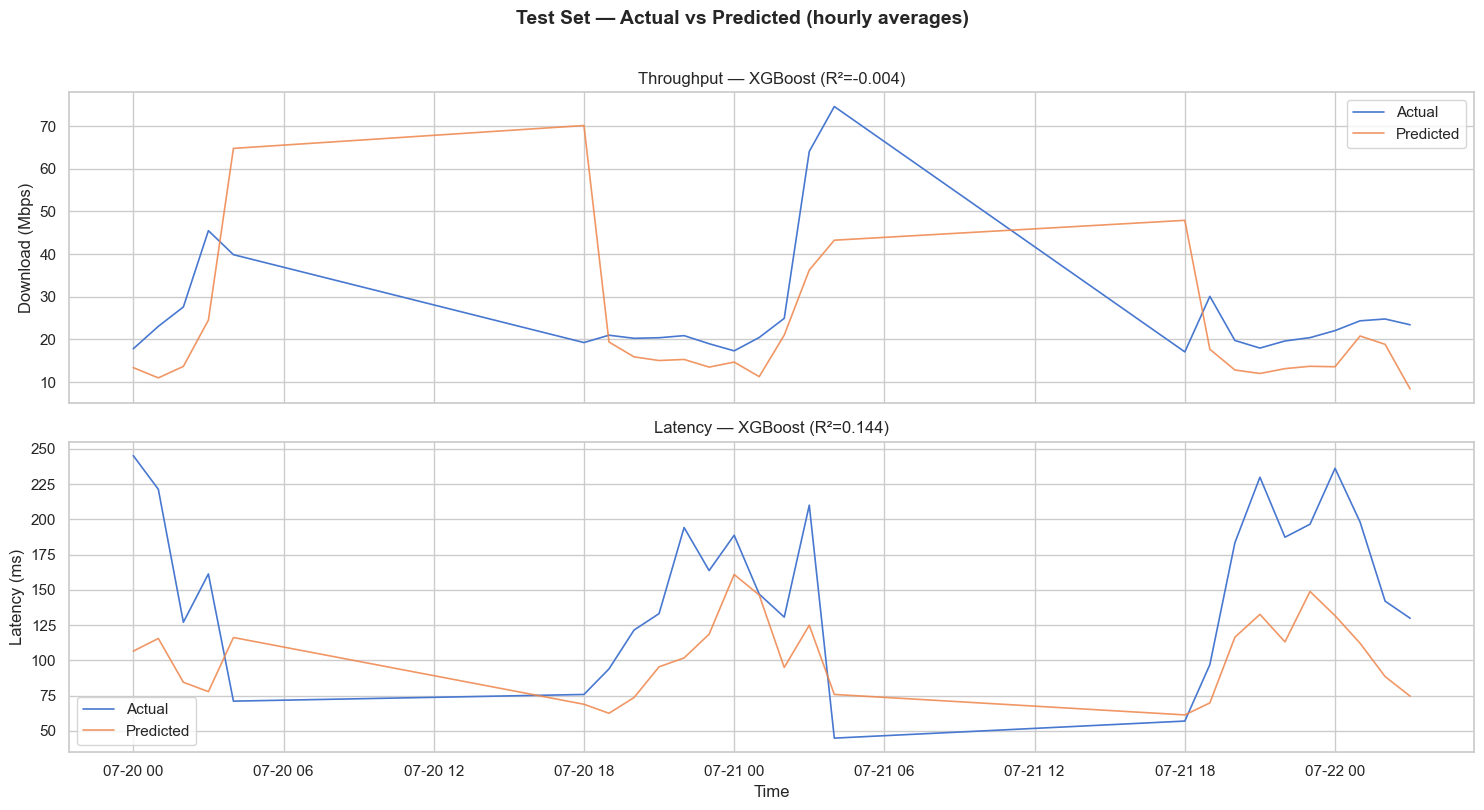

In [41]:
# ── 4b. Actual vs Predicted — hourly-averaged time-series ─
_plot = test_df[["Timestamp"]].copy()
_plot["actual_dl"]  = np.expm1(y_test_dl.values)
_plot["pred_dl"]    = pred_test_dl
_plot["actual_lat"] = np.expm1(y_test_lat.values)
_plot["pred_lat"]   = pred_test_lat

hourly_plot = _plot.set_index("Timestamp").resample("1h").mean().dropna()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(hourly_plot.index, hourly_plot["actual_dl"],  label="Actual",    lw=1.2)
axes[0].plot(hourly_plot.index, hourly_plot["pred_dl"],    label="Predicted", lw=1.2, alpha=0.85)
axes[0].set(ylabel="Download (Mbps)",
            title=f"Throughput — {best_dl_name} (R²={metrics_dl['R2']:.3f})")
axes[0].legend()

axes[1].plot(hourly_plot.index, hourly_plot["actual_lat"], label="Actual",    lw=1.2)
axes[1].plot(hourly_plot.index, hourly_plot["pred_lat"],   label="Predicted", lw=1.2, alpha=0.85)
axes[1].set(ylabel="Latency (ms)", xlabel="Time",
            title=f"Latency — {best_lat_name} (R²={metrics_lat['R2']:.3f})")
axes[1].legend()

fig.suptitle("Test Set — Actual vs Predicted (hourly averages)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

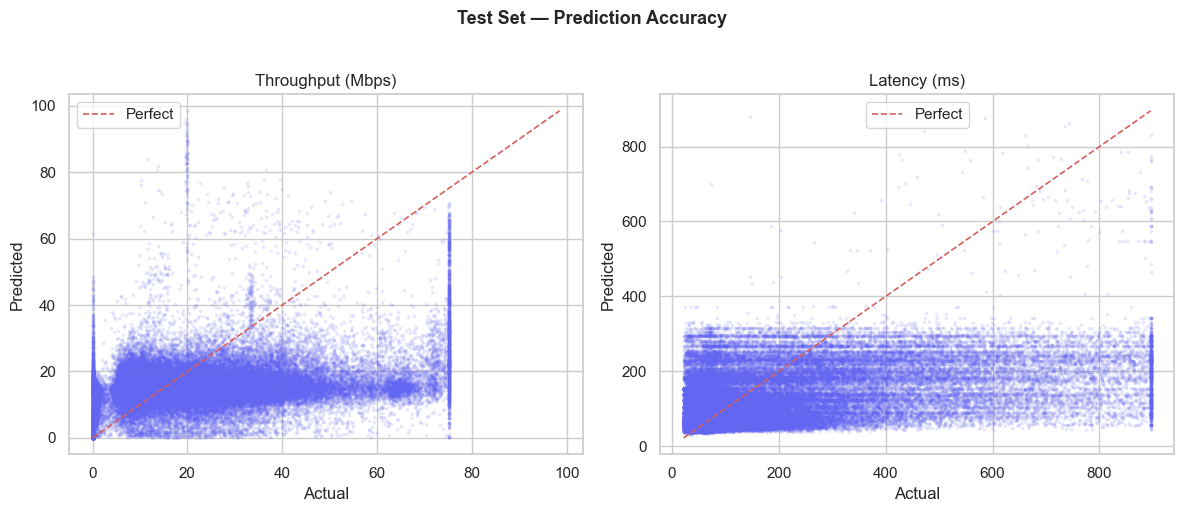

In [42]:
# ── 4c. Scatter plots — Actual vs Predicted ───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample_n = min(80_000, len(pred_test_dl))
_si = np.random.RandomState(42).choice(len(pred_test_dl), sample_n, replace=False)
actual_dl_mbps  = np.expm1(y_test_dl.values)
actual_lat_ms   = np.expm1(y_test_lat.values)

for ax, yt, yp, title in [
    (axes[0], actual_dl_mbps[_si], pred_test_dl[_si], "Throughput (Mbps)"),
    (axes[1], actual_lat_ms[_si],  pred_test_lat[_si], "Latency (ms)"),
]:
    ax.scatter(yt, yp, alpha=0.1, s=3, color="#6366f1")
    lo = min(yt.min(), yp.min())
    hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.2, label="Perfect")
    ax.set(xlabel="Actual", ylabel="Predicted", title=title)
    ax.legend()

fig.suptitle("Test Set — Prediction Accuracy", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

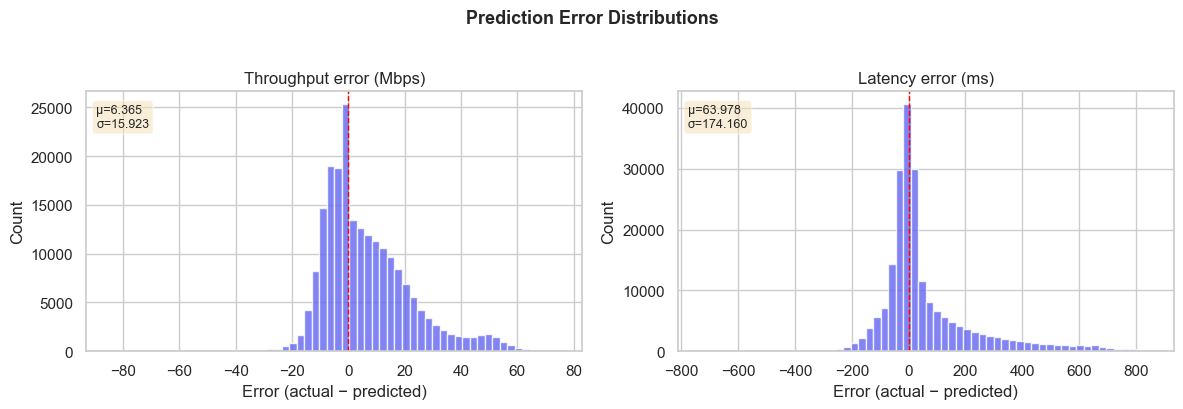

In [43]:
# ── 4d. Error distribution plots ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

errors_dl  = np.expm1(y_test_dl.values) - pred_test_dl
errors_lat = np.expm1(y_test_lat.values) - pred_test_lat

for ax, errs, title in [
    (axes[0], errors_dl,  "Throughput error (Mbps)"),
    (axes[1], errors_lat, "Latency error (ms)"),
]:
    ax.hist(errs, bins=60, color="#6366f1", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", linestyle="--", lw=1)
    ax.set(title=title, xlabel="Error (actual − predicted)", ylabel="Count")
    ax.text(0.02, 0.95, f"μ={errs.mean():.3f}\nσ={errs.std():.3f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

fig.suptitle("Prediction Error Distributions", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

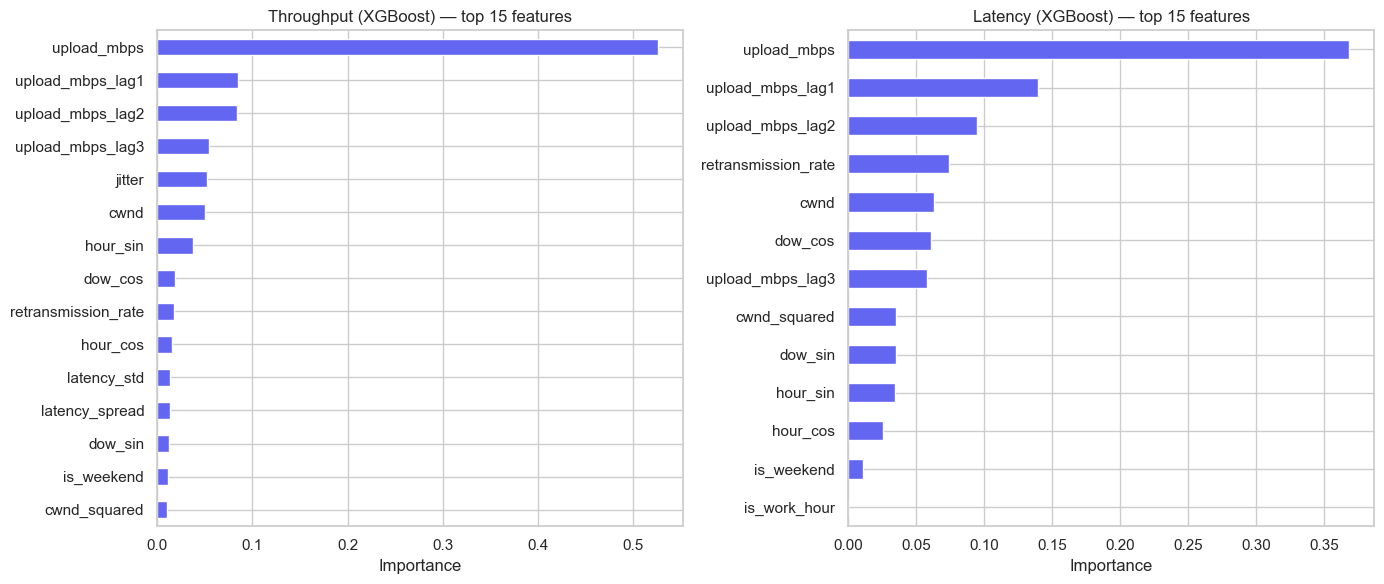

In [44]:
# ── 4e. Feature importance (top 15) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, fcols, title in [
    (axes[0], final_model_dl,  feat_cols_dl,  f"Throughput ({best_dl_name})"),
    (axes[1], final_model_lat, feat_cols_lat, f"Latency ({best_lat_name})"),
]:
    imp = pd.Series(model.feature_importances_, index=fcols)
    top15 = imp.nlargest(15).sort_values()
    top15.plot.barh(ax=ax, color="#6366f1")
    ax.set(title=f"{title} — top 15 features", xlabel="Importance")

fig.tight_layout()
plt.show()

---
## Step 5 — 12-Hour Forecast & Export (Frontend Contract)

Generate exactly **12 rows** (one per future hour) for the Vue dashboard.
Row-level test predictions are aggregated into hourly blocks, then the
model predicts 12 future hours from average recent state.

In [45]:
# ── 5a. 12-hour forecast (leakage-free, per-target features) ─
HORIZON = 12

# Build base feature vectors from recent test data (separate per target)
recent = test_df.sort_values("Timestamp").tail(2000)
base_row_dl  = pd.DataFrame(recent[feat_cols_dl].mean().values.reshape(1, -1),  columns=feat_cols_dl)
base_row_lat = pd.DataFrame(recent[feat_cols_lat].mean().values.reshape(1, -1), columns=feat_cols_lat)

last_ts = test_df["Timestamp"].max()

# Verify no leaky features remain
_all_leaky = _exclude_leaky | _exclude_raw_source
assert not (_all_leaky & set(feat_cols_dl)),  f"Leaky in DL: {_all_leaky & set(feat_cols_dl)}"
assert not (_all_leaky & set(feat_cols_lat)), f"Leaky in LAT: {_all_leaky & set(feat_cols_lat)}"

forecast_rows = []
for step in range(1, HORIZON + 1):
    next_ts = last_ts + pd.Timedelta(hours=step)
    row_dl  = base_row_dl.copy()
    row_lat = base_row_lat.copy()

    # Update temporal features for both
    h, d = next_ts.hour, next_ts.dayofweek
    for row, fcols in [(row_dl, feat_cols_dl), (row_lat, feat_cols_lat)]:
        if "hour_sin"     in fcols: row["hour_sin"]     = np.sin(2 * np.pi * h / 24)
        if "hour_cos"     in fcols: row["hour_cos"]     = np.cos(2 * np.pi * h / 24)
        if "dow_sin"      in fcols: row["dow_sin"]      = np.sin(2 * np.pi * d / 7)
        if "dow_cos"      in fcols: row["dow_cos"]      = np.cos(2 * np.pi * d / 7)
        if "is_weekend"   in fcols: row["is_weekend"]   = int(d >= 5)
        if "is_work_hour" in fcols: row["is_work_hour"] = int(d < 5 and 8 <= h <= 17)

    pred_throughput = float(np.maximum(np.expm1(final_model_dl.predict(row_dl)[0]), 0))
    pred_latency    = float(np.maximum(np.expm1(final_model_lat.predict(row_lat)[0]), 0))

    forecast_rows.append({
        "timestamp":            next_ts.strftime("%Y-%m-%d %H:%M"),
        "predicted_throughput": round(pred_throughput, 2),
        "predicted_latency":   round(pred_latency, 2),
    })

forecast_df = pd.DataFrame(forecast_rows)
print(f"12-hour forecast generated ({len(forecast_df)} rows)")
print(f"DL model: {len(feat_cols_dl)} features | LAT model: {len(feat_cols_lat)} features")
forecast_df

12-hour forecast generated (12 rows)
DL model: 16 features | LAT model: 13 features


,timestamp,predicted_throughput,predicted_latency
0,2022-07-22 04:53,33.73,197.29
1,2022-07-22 05:53,33.83,175.88
2,2022-07-22 06:53,37.99,178.30
3,2022-07-22 07:53,48.49,187.47
4,2022-07-22 08:53,48.34,195.36
5,2022-07-22 09:53,38.01,257.61
6,2022-07-22 10:53,28.85,300.23
7,2022-07-22 11:53,26.25,246.07
8,2022-07-22 12:53,23.27,219.87
9,2022-07-22 13:53,22.79,220.59


In [46]:
# ── 5b. Export forecast_data.csv ──────────────────────────
forecast_path = METRICS_DIR / "forecast_data.csv"
forecast_df.to_csv(forecast_path, index=False)
print(f"✓ Saved {forecast_path}  ({len(forecast_df)} rows)")
print(f"  Columns: {list(forecast_df.columns)}")
forecast_df.head()

✓ Saved metrics\forecast_data.csv  (12 rows)
  Columns: ['timestamp', 'predicted_throughput', 'predicted_latency']


,timestamp,predicted_throughput,predicted_latency
0,2022-07-22 04:53,33.73,197.29
1,2022-07-22 05:53,33.83,175.88
2,2022-07-22 06:53,37.99,178.30
3,2022-07-22 07:53,48.49,187.47
4,2022-07-22 08:53,48.34,195.36


---
## Step 6 — Save Model Artefacts

In [47]:
joblib.dump(final_model_dl,  MODELS_DIR / f"forecast_dl_{best_dl_name}.pkl")
joblib.dump(final_model_lat, MODELS_DIR / f"forecast_lat_{best_lat_name}.pkl")

# Save metadata for the backend to know which models to load
meta = {
    "best_dl_model":  best_dl_name,
    "best_lat_model": best_lat_name,
    "feat_cols_dl":   feat_cols_dl,
    "feat_cols_lat":  feat_cols_lat,
    "dl_winsorize":   [float(dl_lo), float(dl_hi)],
    "lat_winsorize":  [float(lat_lo), float(lat_hi)],
}
joblib.dump(meta, MODELS_DIR / "forecast_meta.pkl")

print(f"✓ Saved models to {MODELS_DIR.resolve()}:")
for p in sorted(MODELS_DIR.glob("forecast_*.pkl")):
    print(f"    {p.name:<36} {p.stat().st_size / 1024:>8.1f} KB")

✓ Saved models to D:\Study\Bachelor SUT\Year 4 - Final Unit\Spring 2026\COS40007 - Artificial Intelligence Engineering\Final Project\AI4Eng_Theme5\backend\models:
    forecast_dl_LightGBM.pkl                879.7 KB
    forecast_dl_XGBoost.pkl                2649.8 KB
    forecast_lat_LightGBM.pkl               868.6 KB
    forecast_lat_XGBoost.pkl               2613.6 KB
    forecast_meta.pkl                         0.4 KB


---
## Step 7 — Final Verification

In [48]:
print("=" * 60)
print("  5G Forecasting Pipeline — Summary")
print("=" * 60)

fc_check = pd.read_csv(METRICS_DIR / "forecast_data.csv")
print(f"\n✓ forecast_data.csv   : {len(fc_check)} hourly predictions")
print(f"  Columns             : {list(fc_check.columns)}")
print(f"  Throughput range    : {fc_check['predicted_throughput'].min():.2f} – "
      f"{fc_check['predicted_throughput'].max():.2f} Mbps")
print(f"  Latency range       : {fc_check['predicted_latency'].min():.2f} – "
      f"{fc_check['predicted_latency'].max():.2f} ms")

print(f"\n✓ Model artefacts:")
for p in sorted(MODELS_DIR.glob("forecast_*.pkl")):
    print(f"    {p.name:<36} {p.stat().st_size / 1024:>8.1f} KB")

print(f"\n✓ Throughput — R²={metrics_dl['R2']:.4f}  MAE={metrics_dl['MAE']:.3f}  "
      f"RMSE={metrics_dl['RMSE']:.3f}  MAPE={metrics_dl['MAPE']:.4f}")
print(f"  Latency    — R²={metrics_lat['R2']:.4f}  MAE={metrics_lat['MAE']:.3f}  "
      f"RMSE={metrics_lat['RMSE']:.3f}  MAPE={metrics_lat['MAPE']:.4f}")

print("\n" + "=" * 60)
print("  Pipeline complete. Frontend contract verified.")
print("=" * 60)

  5G Forecasting Pipeline — Summary

✓ forecast_data.csv   : 12 hourly predictions
  Columns             : ['timestamp', 'predicted_throughput', 'predicted_latency']
  Throughput range    : 22.31 – 48.49 Mbps
  Latency range       : 175.88 – 300.23 ms

✓ Model artefacts:
    forecast_dl_LightGBM.pkl                879.7 KB
    forecast_dl_XGBoost.pkl                2649.8 KB
    forecast_lat_LightGBM.pkl               868.6 KB
    forecast_lat_XGBoost.pkl               2613.6 KB
    forecast_meta.pkl                         0.4 KB

✓ Throughput — R²=-0.0039  MAE=12.101  RMSE=17.148  MAPE=1628713856279305.5000
  Latency    — R²=0.1442  MAE=108.142  RMSE=185.540  MAPE=0.7190

  Pipeline complete. Frontend contract verified.
